# 1. Importationns des bibliothèques 

In [1]:
# importation des données
import pandas as pd
import numpy as np

# visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

#prétraitement 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder

# modèlisation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import  DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# evaluation
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score,precision_score,recall_score)

#sauvegarde des artefacts
import joblib
import os

# configuration de l'affichage 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(9,5)
pd.set_option("display.max_columns", None)

RANDOM_STATE =42
np.random.seed(RANDOM_STATE)

import warnings
warnings.filterwarnings("ignore")

print("libreries importé avec success")



libreries importé avec success


# 2. Chargement des données 

In [2]:
data = pd.read_csv("../data/Crop_recommendation.csv")
print(f"Dimensions du dataset {data.shape[0]} lignes x {data.shape[1]} colonnes")
data.head()

Dimensions du dataset 2200 lignes x 8 colonnes


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


***Commentaire :*** nous avons 7 features qui sont : `N`, `P`, `K`,`temperature`,`humidity`, `ph`, `rainfall` et la variable cible `label` 

# 3. Explorations initiale des données

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


***Commentaire :*** Les features de notre dataset ne sont que des variables numériques, ce n'est que la variable cible qui est catégorielle. Le dataset ne contient pas de valeurs manquantes puisque sur la colonne `Non-Null`  nous observons que toutes les colonnes affichent `2200`.                                                           
***Types de donées*** : `N`, `P`, `K` sont des  entières (int64)                                      
`temperature`,`humidity`, `ph`, `rainfall` sont des reels (float64) et
`label` variable cible chaine de caratère (str)


In [4]:
# Verifications des valeurs manquantes 
print("Valeurs manquantes par colonnes: ")
print(data.isnull().sum())
print(f"Total de valeurs manquantes : {data.isnull().sum().sum()}")

Valeurs manquantes par colonnes: 
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Total de valeurs manquantes : 0


***Commentaire :*** Ce resultat justifie le fais qu'il y a pas de valeurs maquantes comme bien precisé dans le commentaire précédents

In [5]:
# Verifications des doublons
nb_doublons = data.duplicated().sum()
print(f"Nombre de lignes strictement dupliquées : {nb_doublons}")


Nombre de lignes strictement dupliquées : 0


In [6]:
#Statistiques descriptives de la variable catégorielles
data.describe(include='object').T

,count,unique,top,freq
label,2200,22,rice,100


# Description de la variable cible

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


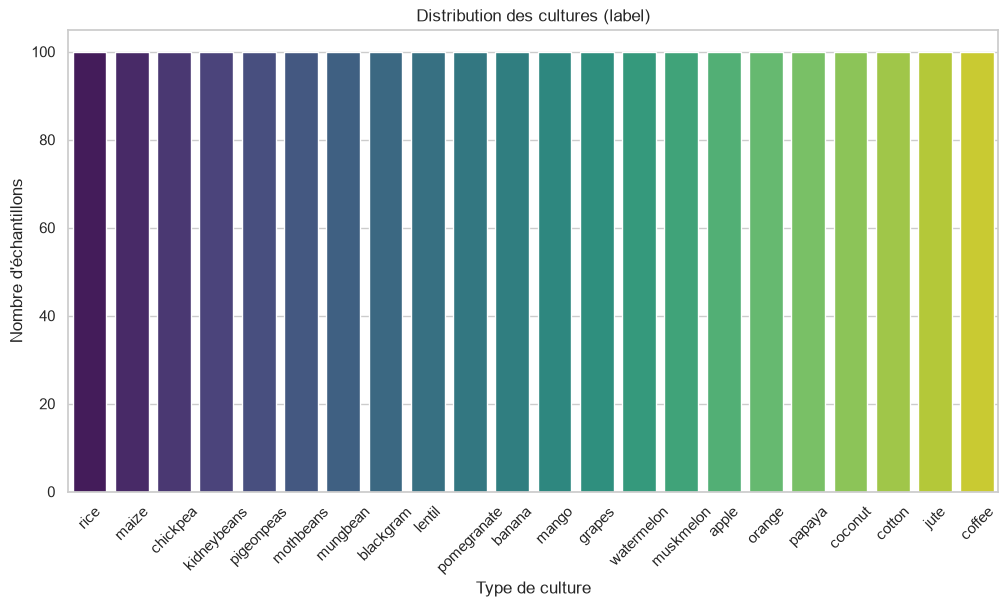

In [7]:
# Compter les occurrences de chaque culture
label_counts = data['label'].value_counts()
#Afficher les effectis
print(label_counts)

# Tracer un barplot
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution des cultures (label)')
plt.xlabel('Type de culture')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(rotation=45)
plt.show()

***Commentaire :*** Cette distribution des classes de la varible cible  montre que les 22 cultures sont representées par exactement 100 echantillons chacun et  bien equilibrées du coup pas besoins des techniques de reéquilibrage de la variable cible nous pouvons donc nous focaliser sur l'accuracy et le f1 score macro

In [8]:
num_cols= data.select_dtypes(include=["int64", "float64"]).columns
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


***Commentaire :*** Nous pouvons constater qu'il y'a presence des valeurs aberrantes sur certaines variables et aussi savoir  la dispersion de ma distribution 

In [9]:
#detections des valeurs abérantes
def detecter_outliers(col):
    q1,q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_inf ,borne_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((data[col]< borne_inf) | (data[col]>borne_sup)).sum()
    return outliers

for col in num_cols :
    outliers = detecter_outliers(col)
    print(f"{col} - Nombre de valeurs aberrantes : {outliers}")


N - Nombre de valeurs aberrantes : 0
P - Nombre de valeurs aberrantes : 138
K - Nombre de valeurs aberrantes : 200
temperature - Nombre de valeurs aberrantes : 86
humidity - Nombre de valeurs aberrantes : 30
ph - Nombre de valeurs aberrantes : 57
rainfall - Nombre de valeurs aberrantes : 100


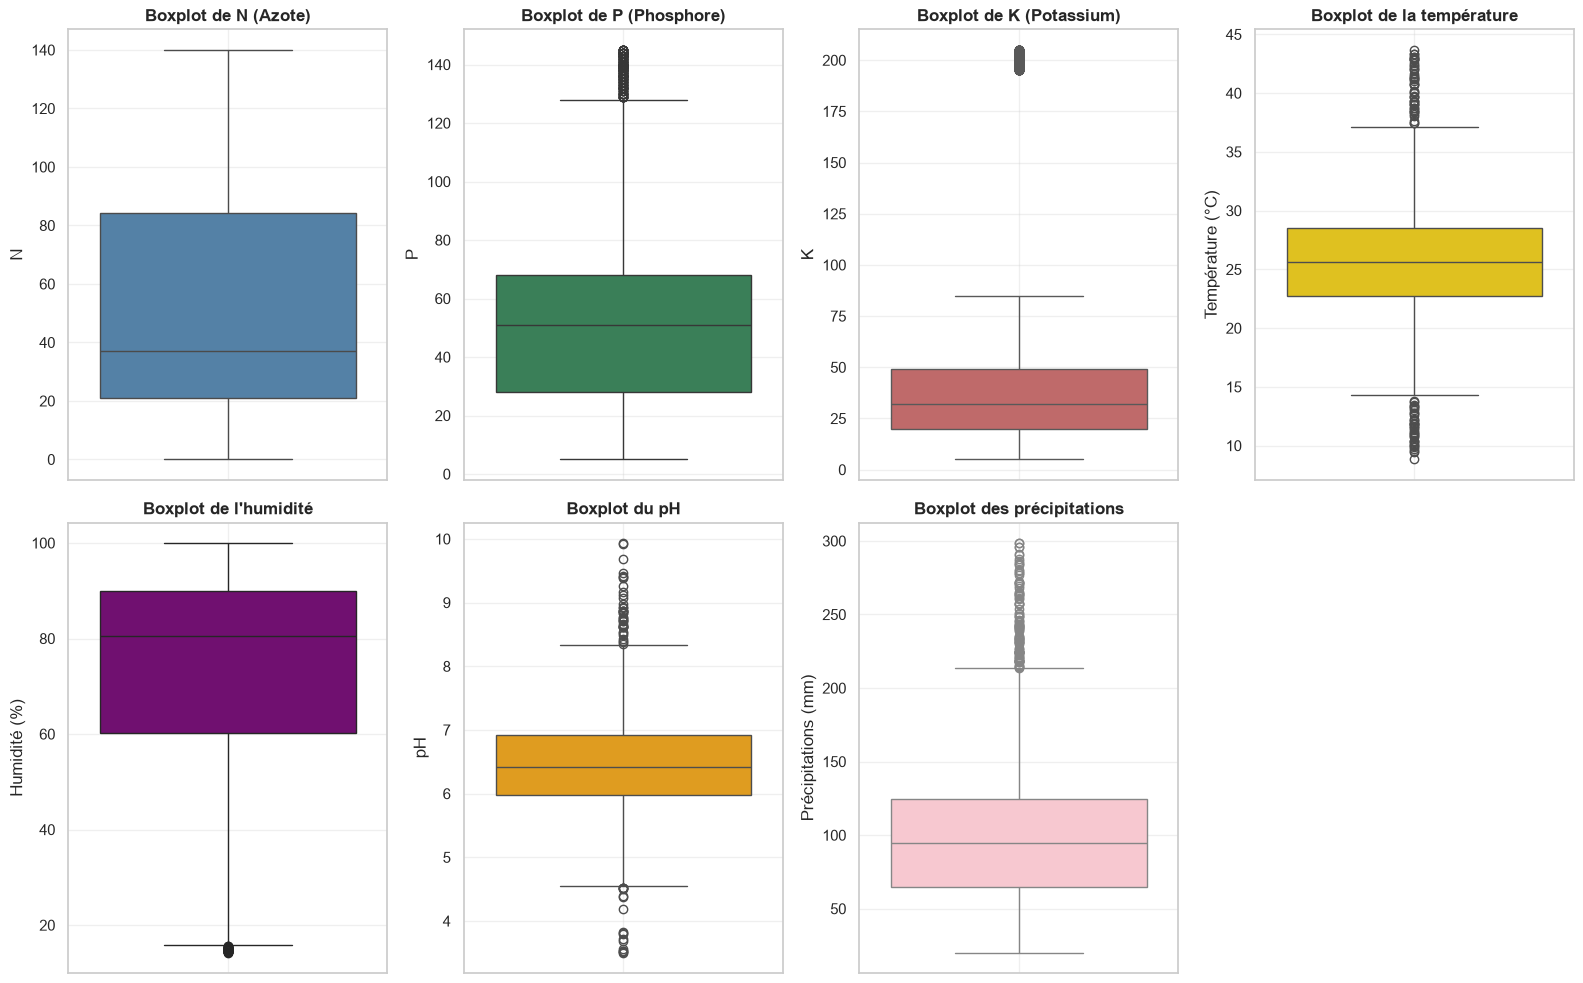

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

sns.boxplot(y=data["N"], ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Boxplot de N (Azote)", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("N")
axes[0,0].grid(True, alpha=0.3)

sns.boxplot(y=data["P"], ax=axes[0,1], color="seagreen")
axes[0,1].set_title("Boxplot de P (Phosphore)", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("P")
axes[0,1].grid(True, alpha=0.3)

sns.boxplot(y=data["K"], ax=axes[0,2], color="indianred")
axes[0,2].set_title("Boxplot de K (Potassium)", fontsize=12, fontweight='bold')
axes[0,2].set_ylabel("K")
axes[0,2].grid(True, alpha=0.3)

sns.boxplot(y=data["temperature"], ax=axes[0,3], color="gold")
axes[0,3].set_title("Boxplot de la température", fontsize=12, fontweight='bold')
axes[0,3].set_ylabel("Température (°C)")
axes[0,3].grid(True, alpha=0.3)


sns.boxplot(y=data["humidity"], ax=axes[1,0], color="purple")
axes[1,0].set_title("Boxplot de l'humidité", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Humidité (%)")
axes[1,0].grid(True, alpha=0.3)

sns.boxplot(y=data["ph"], ax=axes[1,1], color="orange")
axes[1,1].set_title("Boxplot du pH", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("pH")
axes[1,1].grid(True, alpha=0.3)

sns.boxplot(y=data["rainfall"], ax=axes[1,2], color="pink")
axes[1,2].set_title("Boxplot des précipitations", fontsize=12, fontweight='bold')
axes[1,2].set_ylabel("Précipitations (mm)")
axes[1,2].grid(True, alpha=0.3)

# Cacher le dernier subplot vide (7 variables -> 8 emplacements)
axes[1,3].set_visible(False)

plt.tight_layout()
plt.show()

***Commentaire :*** "L'analyse des boîtes à moustaches révèle la présence de valeurs aberrantes, notamment pour les variables K (200 outliers), P (138 outliers), temperature (86 outliers), humidity (30 outliers), ph (57 outliers) et rainfall (100 outliers). Toutefois, ces valeurs extrêmes correspondent aux exigences spécifiques de certaines cultures . Elles ne sont donc pas considérées comme des erreurs de saisie mais comme des signatures culturales. Nous les conserverons pour l'entraînement des modèles."

In [11]:
#Copie du dataset
df = data.copy()

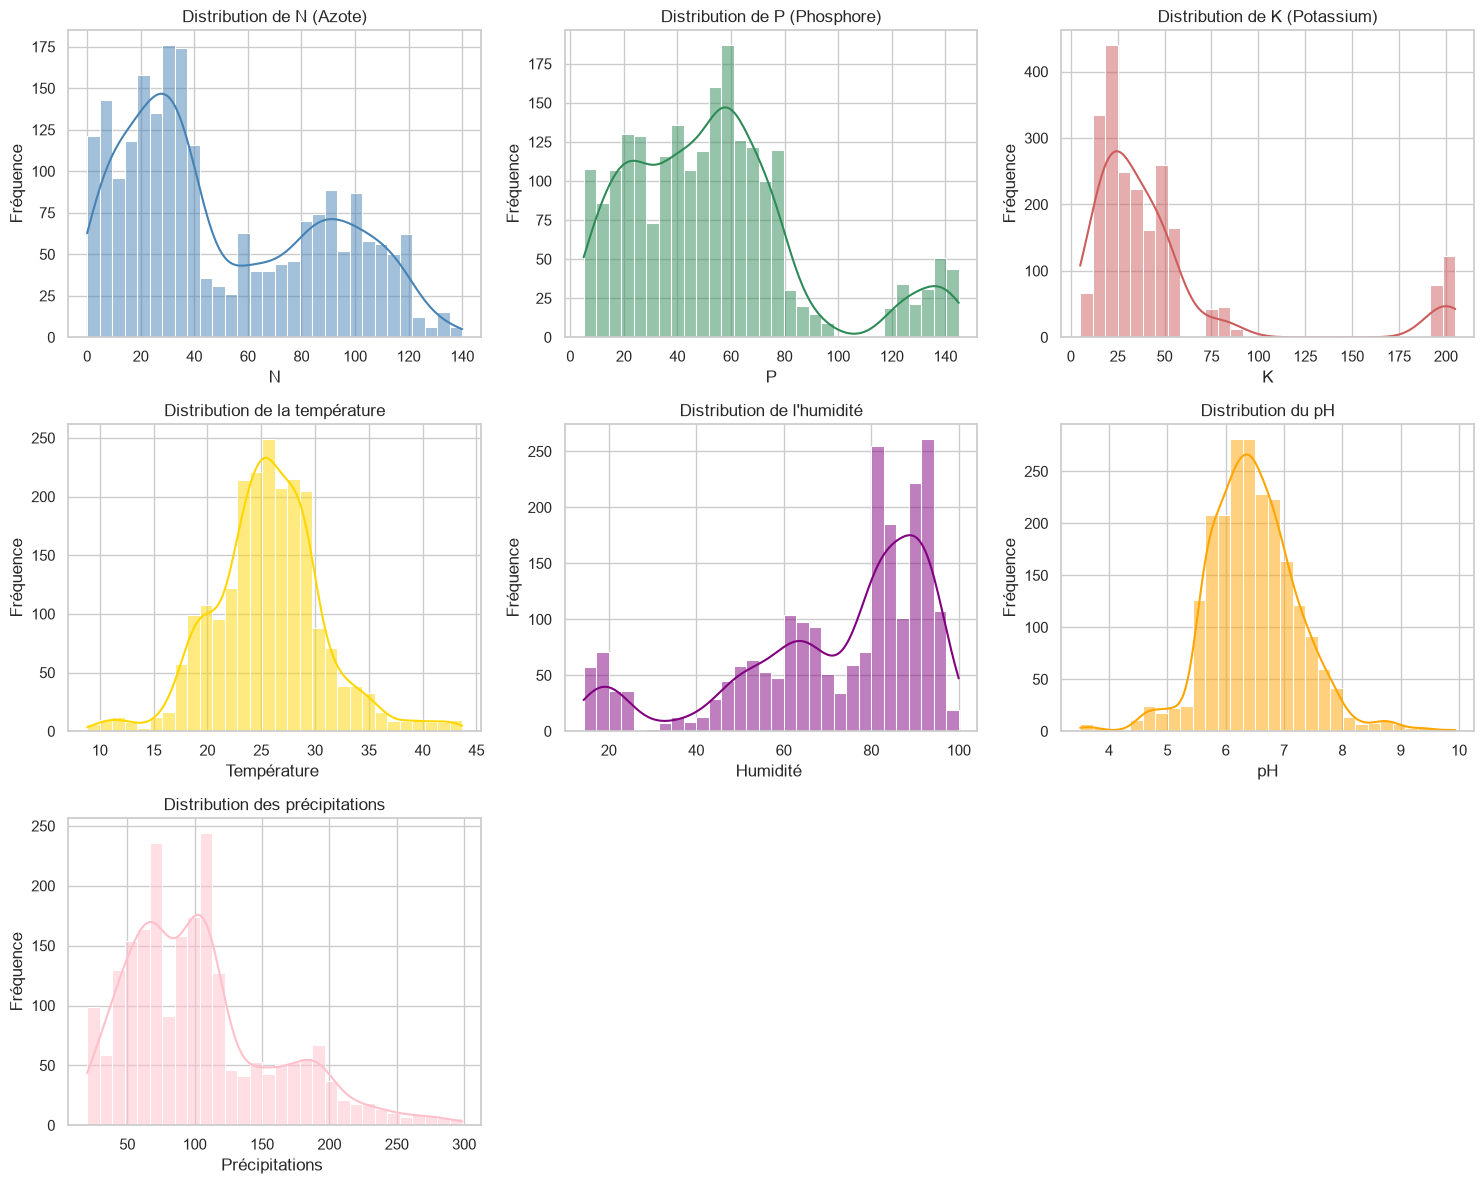

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

sns.histplot(df["N"], bins=30, kde=True, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Distribution de N (Azote)")
axes[0,0].set_xlabel("N")
axes[0,0].set_ylabel("Fréquence")

sns.histplot(df["P"], bins=30, kde=True, ax=axes[0,1], color="seagreen")
axes[0,1].set_title("Distribution de P (Phosphore)")
axes[0,1].set_xlabel("P")
axes[0,1].set_ylabel("Fréquence")

sns.histplot(df["K"], bins=30, kde=True, ax=axes[0,2], color="indianred")
axes[0,2].set_title("Distribution de K (Potassium)")
axes[0,2].set_xlabel("K")
axes[0,2].set_ylabel("Fréquence")


sns.histplot(df["temperature"], bins=30, kde=True, ax=axes[1,0], color="gold")
axes[1,0].set_title("Distribution de la température")
axes[1,0].set_xlabel("Température ")
axes[1,0].set_ylabel("Fréquence")

sns.histplot(df["humidity"], bins=30, kde=True, ax=axes[1,1], color="purple")
axes[1,1].set_title("Distribution de l'humidité")
axes[1,1].set_xlabel("Humidité ")
axes[1,1].set_ylabel("Fréquence")

sns.histplot(df["ph"], bins=30, kde=True, ax=axes[1,2], color="orange")
axes[1,2].set_title("Distribution du pH")
axes[1,2].set_xlabel("pH")
axes[1,2].set_ylabel("Fréquence")


sns.histplot(df["rainfall"], bins=30, kde=True, ax=axes[2,0], color="pink")
axes[2,0].set_title("Distribution des précipitations")
axes[2,0].set_xlabel("Précipitations ")
axes[2,0].set_ylabel("Fréquence")

# Cacher les deux subplots vides (en bas à droite)
axes[2,1].set_visible(False)
axes[2,2].set_visible(False)

plt.tight_layout()
plt.show()

# 4.Analyse les correlations 

<Axes: >

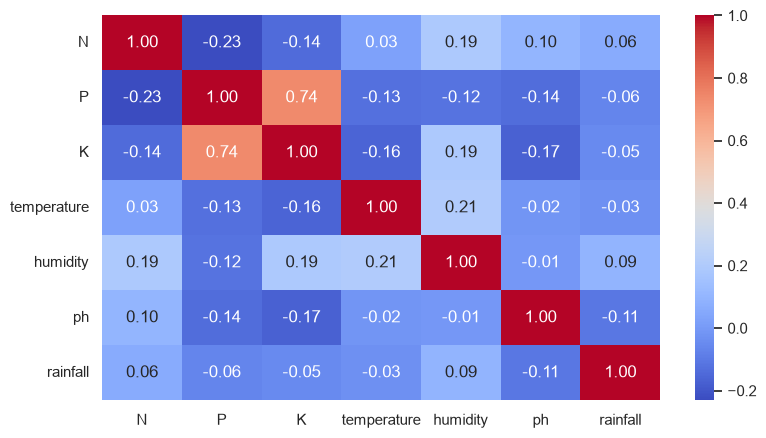

In [13]:
#Corrélation entre les variables numériques ?
cor = df[num_cols].corr()
sns.heatmap(cor, annot=True, cmap="coolwarm", fmt=".2f")

***Commentaire :*** L'analyse de la matrice de corrélation révèle :
Une forte corrélation positive (0.74) entre le phosphore (P) et le potassium (K).
Les autres corrélations sont faibles (inférieures à 0.5 en valeur absolue), indiquant que les variables sont largement indépendantes.
Cette structure est favorable pour la modélisation : elle limite les risques de multicolinéarité tout en offrant des informations complémentaires.
Pour la modélisation, les modèles basés sur les arbres (Random Forest, XGBoost) sont particulièrement adaptés car ils sont robustes à ce niveau de corrélation."

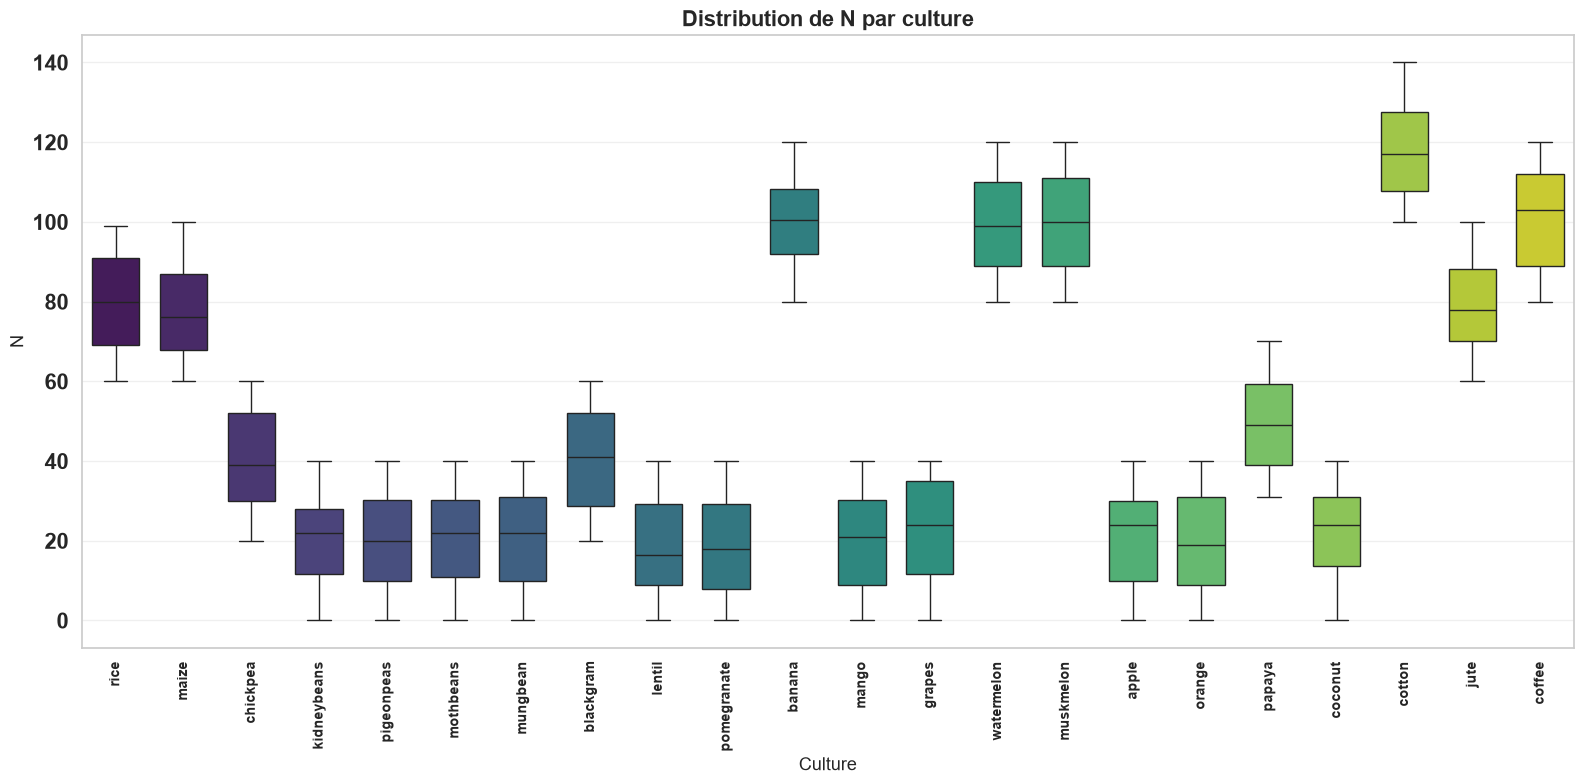

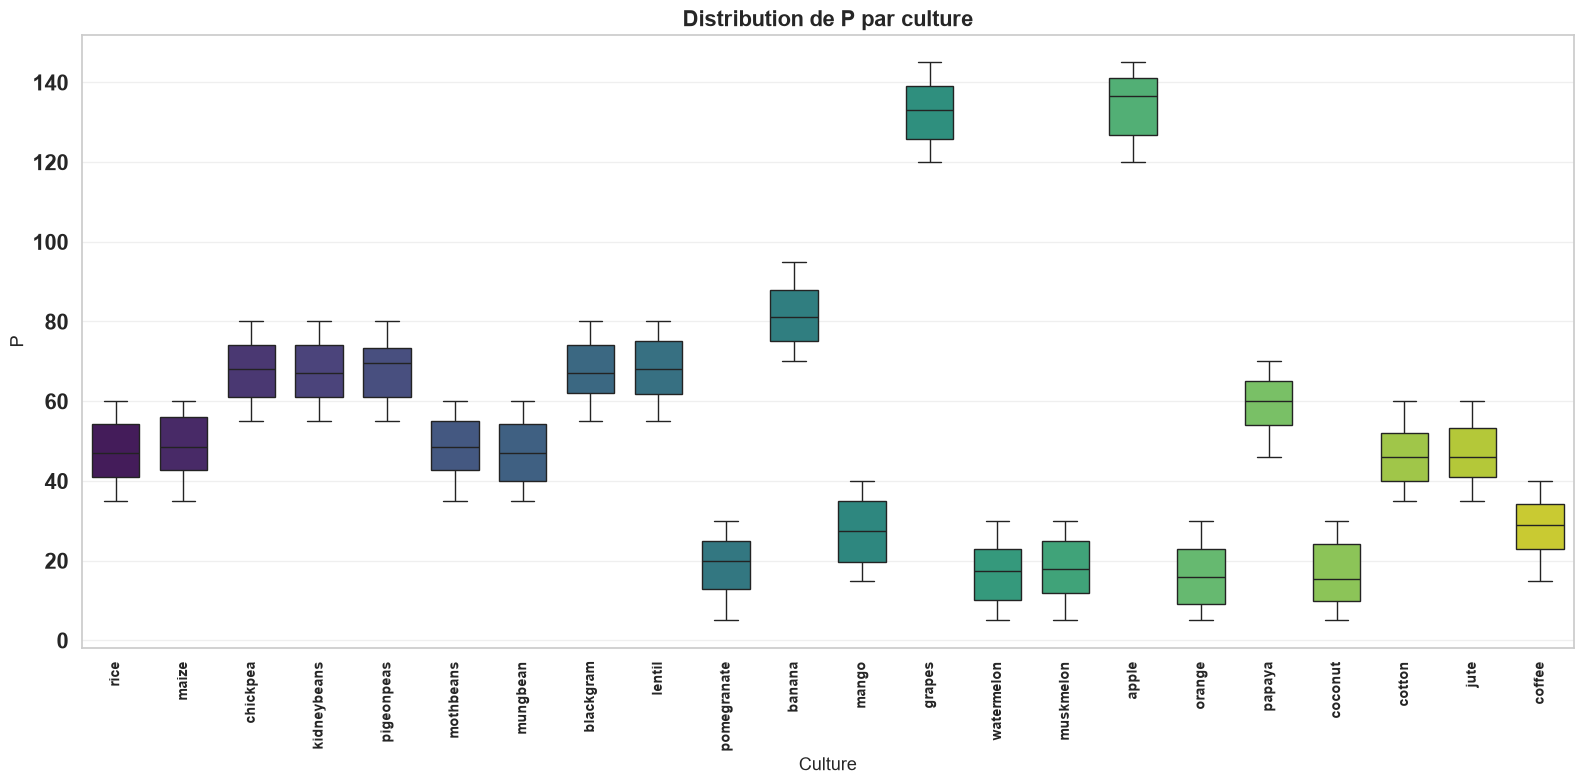

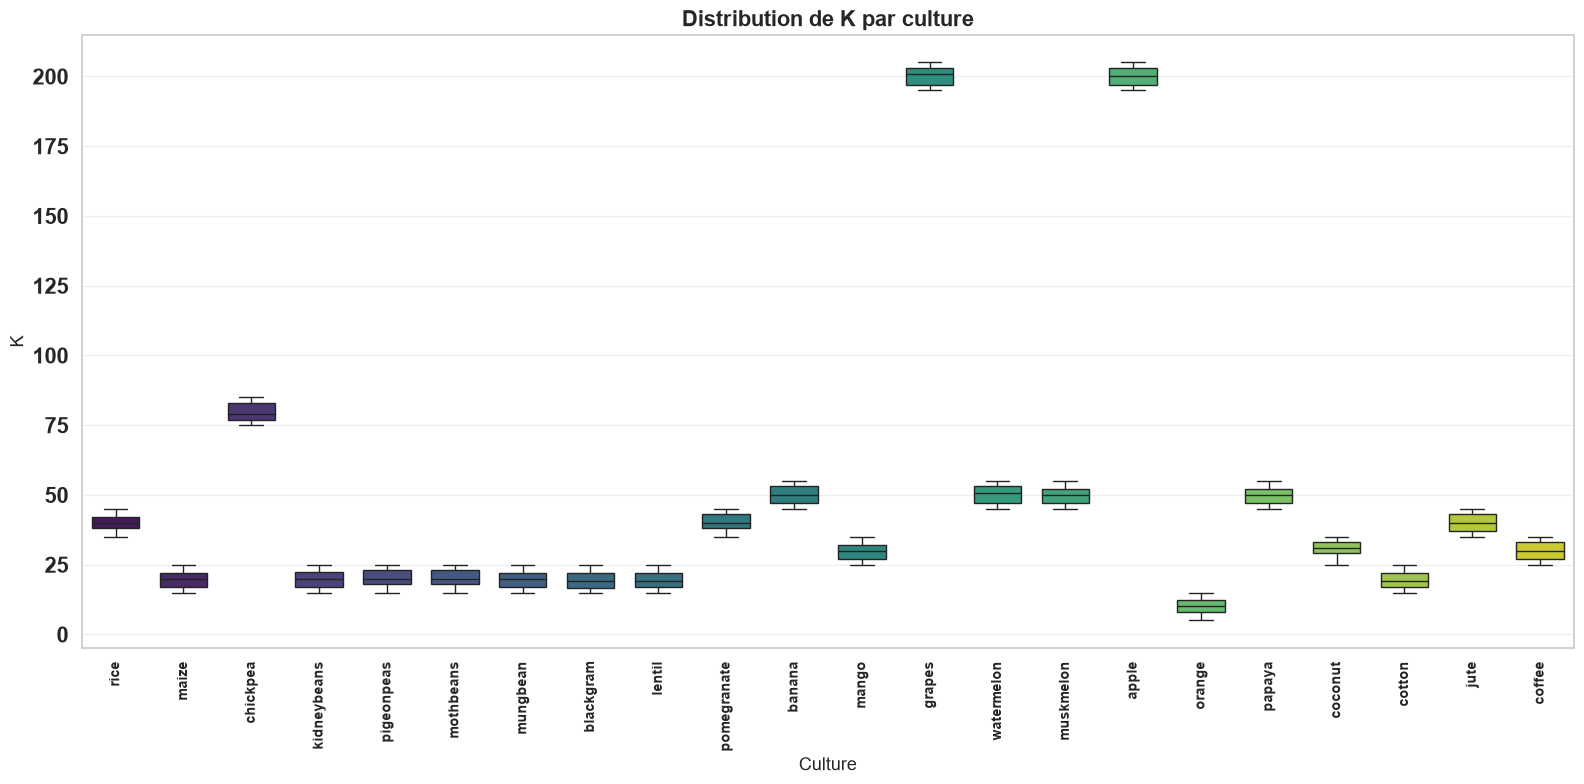

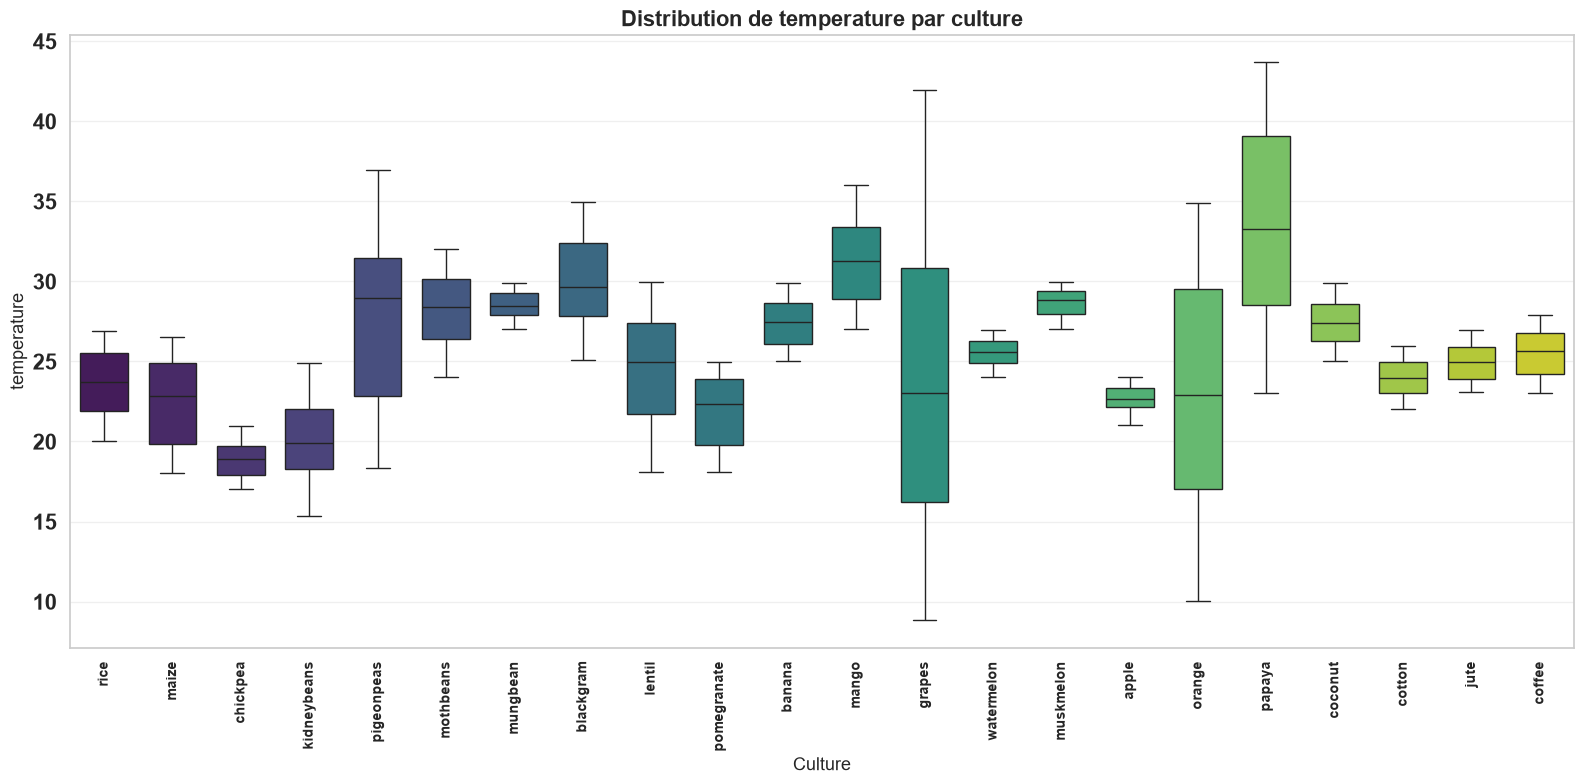

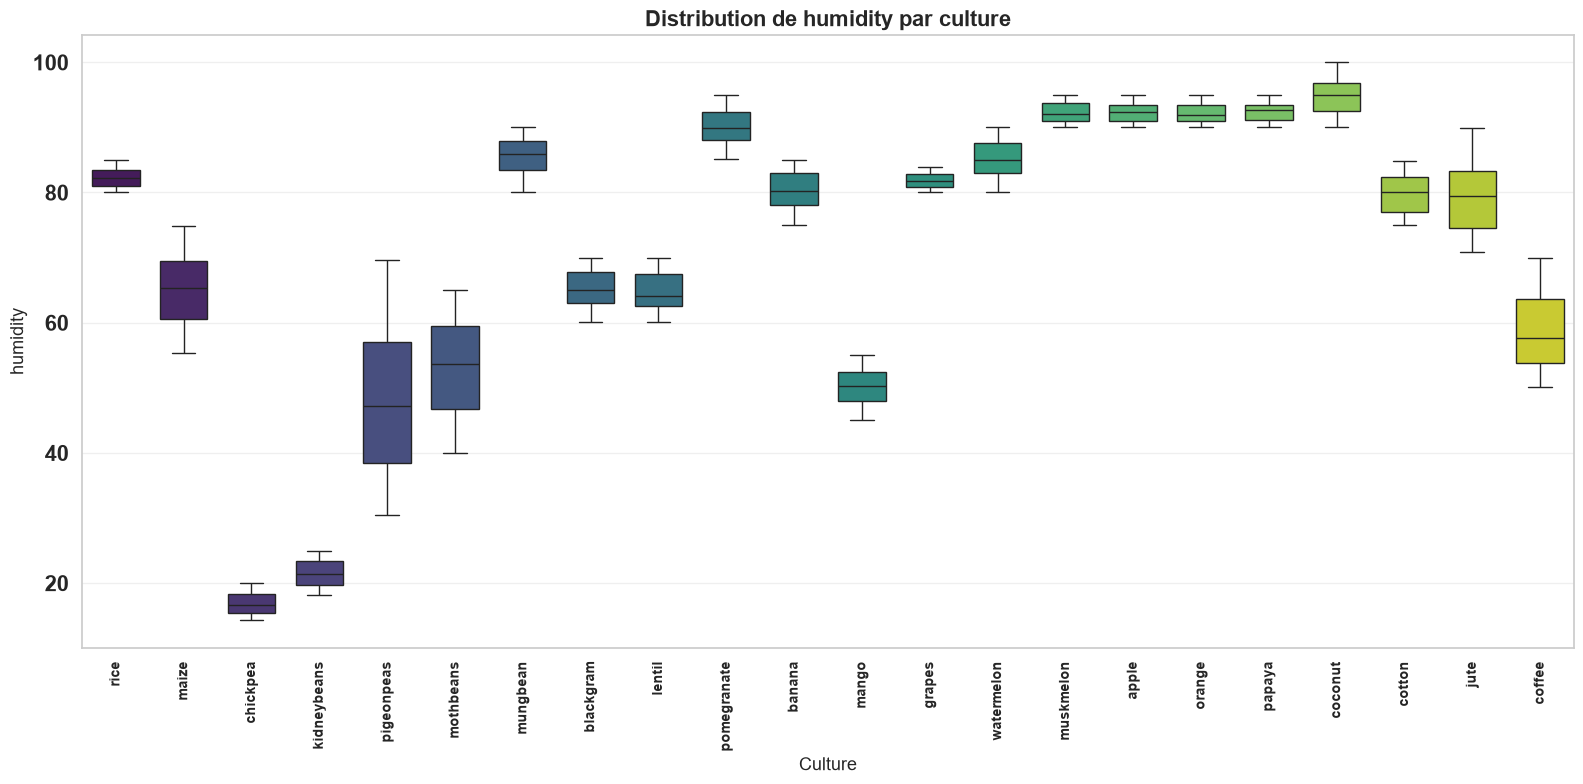

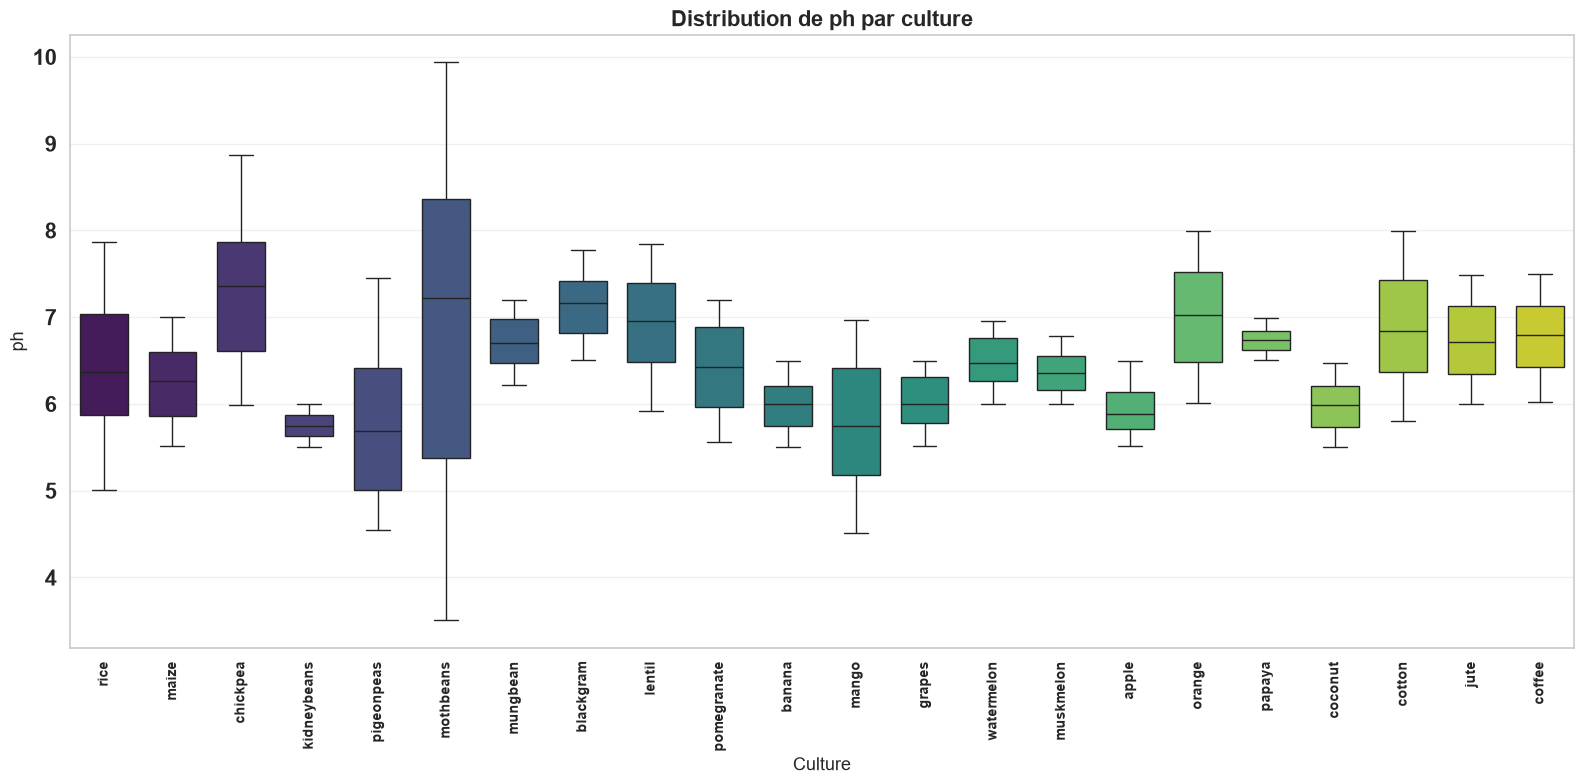

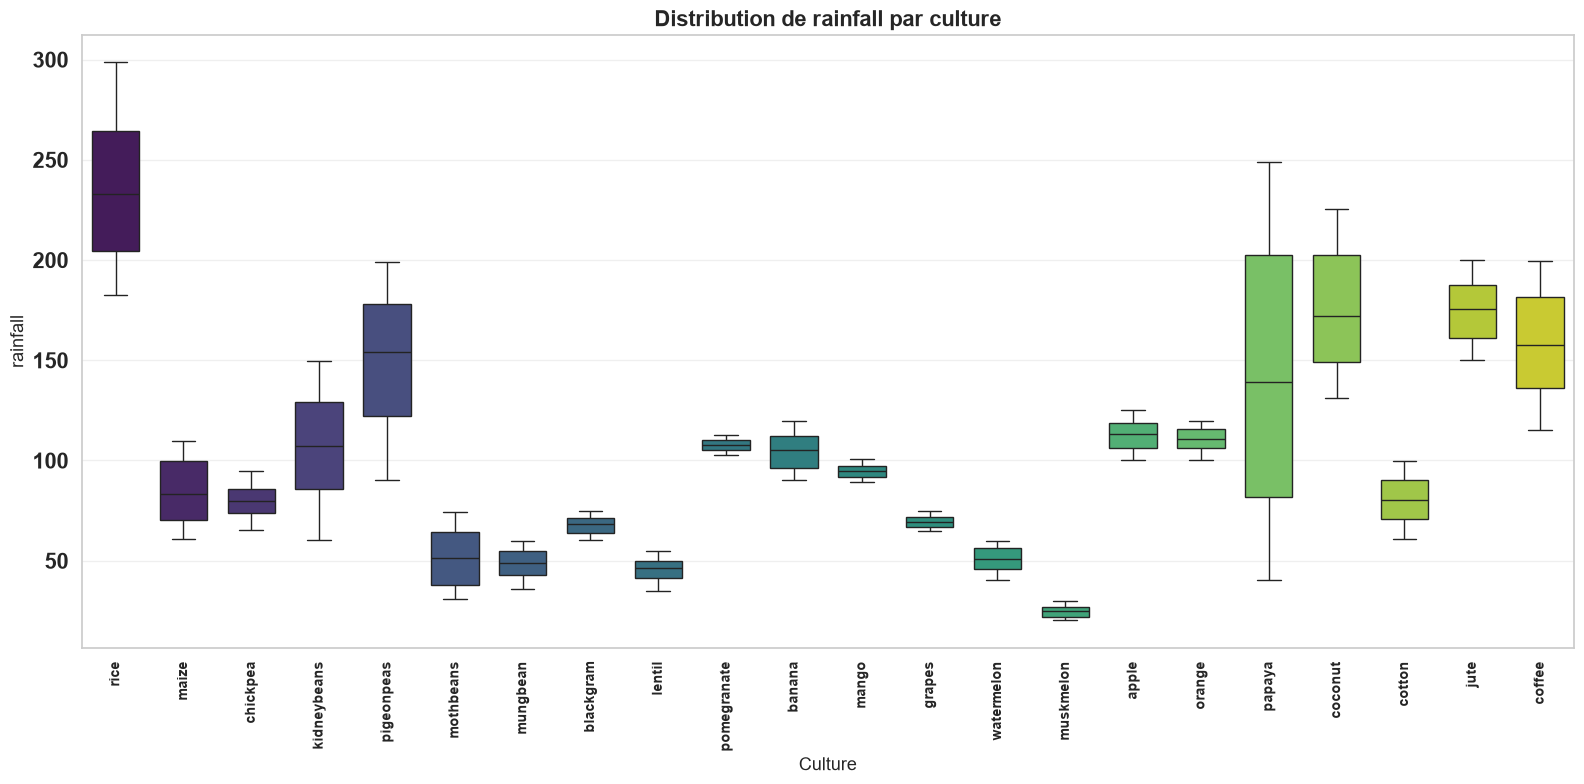

In [ ]:
# Afficher chaque variable dans une figure séparée
for i, col in enumerate(num_cols):
    plt.figure(figsize=(16, 8))
    sns.boxplot(x='label', y=col, data=data, hue='label', palette='viridis', legend=False, width=0.7)
    plt.title(f'Distribution de {col} par culture', fontsize=16, fontweight='bold')
    plt.xlabel('Culture', fontsize=13, fontweight='bold')
    plt.ylabel(col, fontsize=13, fontweight='bold')
    plt.xticks(rotation=90, fontsize=10, fontweight='bold')
    plt.yticks(fontsize=16, fontweight='bold')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

***Commentaire :*** 

# 5. Preparation des données

In [15]:
# Separation des features de la cible et encodage de la variable cible 
X = df[num_cols]
y = df['label']
encodeur_cible = LabelEncoder()
y_encoded = encodeur_cible.fit_transform(y)


In [16]:
#division de l'echantillon
xtrain, xtest, ytrain, ytest = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
print(f"Taille de l'entrainement : {xtrain.shape[0]} observations")
print(f"Taille de l'ensemble de test :{xtest.shape[0]} observations")

Taille de l'entrainement : 1760 observations
Taille de l'ensemble de test :440 observations


***Commentaire :*** Division de l'echantillon en 80% pour l'entrainement et 20% por le test tout en gardant les mêmes proportions 

In [ ]:
#Normalisation
scaler = StandardScaler()
xtrain_scaled= pd.DataFrame(scaler.fit_transform(xtrain),columns=num_cols,index=xtrain.index)
xtest_scaled=pd.DataFrame(scaler.transform(xtest), columns=num_cols, index=xtest.index)
xtrain_scaled.describe().T[["mean","std"]].head(7)

,mean,std
N,2.826022e-17,1.000284
P,8.074349e-17,1.000284
K,5.551115e-17,1.000284
temperature,-2.826022e-16,1.000284
humidity,-1.463476e-16,1.000284


In [18]:
modeles={
    "Régression logistique":LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Arbre de Décission": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE,eval_metric="mlogloss"),
}

resultats=[]

for nom, modele in modeles.items():
    modele.fit(xtrain_scaled,ytrain)
    ypred = modele.predict(xtest_scaled)

    acc= accuracy_score(ytest,ypred)
    f1=f1_score(ytest,ypred,average="macro")
    precision=precision_score(ytest,ypred, average="macro",zero_division=0)
    recall=recall_score(ytest,ypred,average="macro")
    cv_scores = cross_val_score(modele,xtrain_scaled,ytrain,cv=5,scoring="accuracy")

    resultats.append({
        "Modèle":nom,
        "Accuracy(test)": acc,
        "F1-score (macro)": f1,
        "précision (macro)":precision,
        "Rappel (macro)": recall,
        "Accuracy cv (moyenne)": cv_scores.mean(),
        "Accuracy cv (écart-type)":cv_scores.std(),
    })

    print(f"---{nom}---")
    print(f"Accuracy (test):{acc:.4f} | Accuracy cv (5-fold) :{cv_scores.mean():.4f}(+/-{cv_scores.std():.4f})")

---Régression logistique---
Accuracy (test):0.9727 | Accuracy cv (5-fold) :0.9676(+/-0.0113)
---Arbre de Décission---
Accuracy (test):0.9795 | Accuracy cv (5-fold) :0.9847(+/-0.0071)
---Random Forest---
Accuracy (test):0.9955 | Accuracy cv (5-fold) :0.9932(+/-0.0043)
---KNN---
Accuracy (test):0.9795 | Accuracy cv (5-fold) :0.9653(+/-0.0075)
---SVM---
Accuracy (test):0.9841 | Accuracy cv (5-fold) :0.9761(+/-0.0075)
---Gradient Boosting---
Accuracy (test):0.9886 | Accuracy cv (5-fold) :0.9875(+/-0.0069)
---XGBoost---
Accuracy (test):0.9932 | Accuracy cv (5-fold) :0.9886(+/-0.0065)


In [19]:
df_resultats = pd.DataFrame(resultats).sort_values("Accuracy(test)",ascending=False).reset_index(drop=True)
df_resultats

,Modèle,Accuracy(test),F1-score (macro),précision (macro),Rappel (macro),Accuracy cv (moyenne),Accuracy cv (écart-type)
0,Random Forest,0.995455,0.995452,0.995671,0.995455,0.993182,0.004252
1,XGBoost,0.993182,0.993116,0.993506,0.993182,0.988636,0.006478
2,Gradient Boosting,0.988636,0.988723,0.989742,0.988636,0.987500,0.006865
3,SVM,0.984091,0.984038,0.985610,0.984091,0.976136,0.007538
4,Arbre de Décission,0.979545,0.979423,0.980598,0.979545,0.984659,0.007097
5,KNN,0.979545,0.979283,0.980356,0.979545,0.965341,0.007495
6,Régression logistique,0.972727,0.972464,0.974022,0.972727,0.967614,0.011307


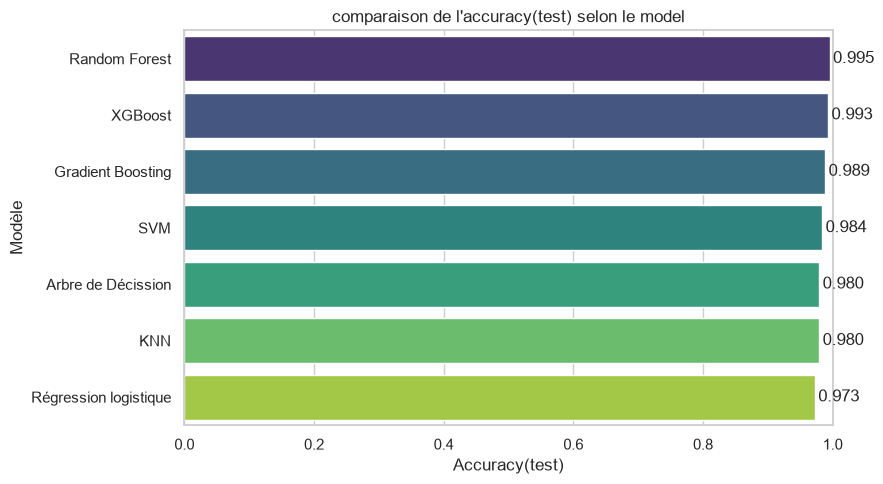

In [20]:
plt.Figure(figsize=(11,6))
sns.barplot(data=df_resultats,x="Accuracy(test)",y="Modèle",hue="Modèle",palette="viridis",legend=False)
plt.title("comparaison de l'accuracy(test) selon le model")
plt.xlim(0,1)
for i,valeur in enumerate(df_resultats["Accuracy(test)"]):
    plt.text(valeur + 0.005,i, f"{valeur:.3f}", va="center")
plt.tight_layout()
plt.show()    


In [21]:
# Rapport de classification détaillé et matrice de confusion pour le meilleur modèle baseline
meilleur_nom=df_resultats.iloc[0]["Modèle"]
meilleur_modele_baseline=modeles[meilleur_nom]
ypred_meilleur=meilleur_modele_baseline.predict(xtest_scaled)

print(f"Meilleur modèle (baseline):{meilleur_nom}\n")
print(classification_report(ytest,ypred_meilleur,target_names=encodeur_cible.classes_))


Meilleur modèle (baseline):Random Forest

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      

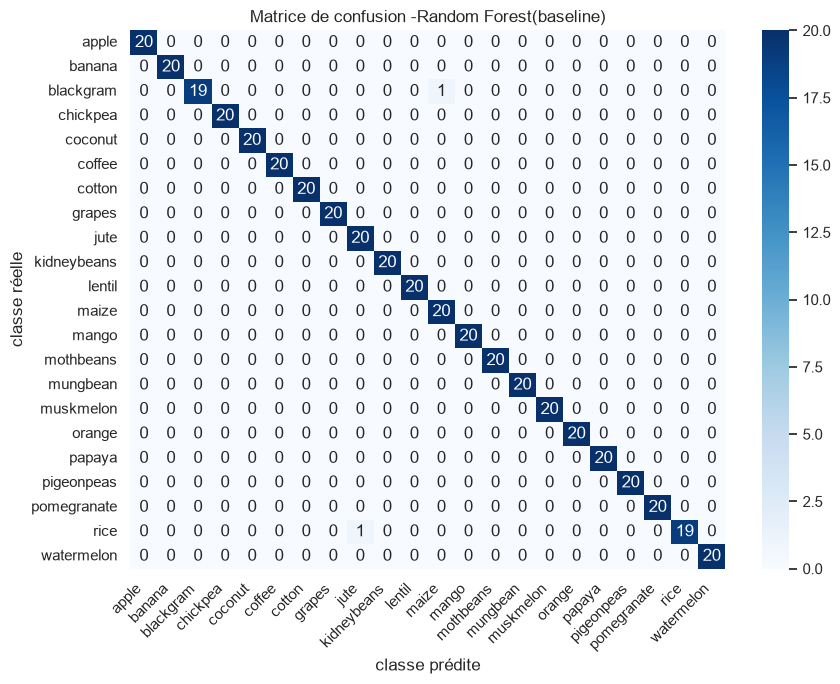

In [22]:
plt.figure(figsize=(9,7))
matrice_confusion = confusion_matrix(ytest,ypred_meilleur)
sns.heatmap(matrice_confusion,annot=True,fmt="d",cmap="Blues",xticklabels=encodeur_cible.classes_,yticklabels=encodeur_cible.classes_)
plt.title(f"Matrice de confusion -{meilleur_nom}(baseline)")
plt.xlabel("classe prédite")
plt.ylabel("classe réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
top_2_modeles= df_resultats["Modèle"].iloc[:2].tolist()
print("Modèles sélectionnés pour l'optimisation :",top_2_modeles)

Modèles sélectionnés pour l'optimisation : ['Random Forest', 'XGBoost']


In [25]:
grilles_hyperparametres={
    "Random Forest":{
        "modele": RandomForestClassifier(random_state=RANDOM_STATE),
        "grille": {
            "n_estimators":[100,200],
            "max_depth":[None, 15],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
        },
    },
    "XGBoost":{
        "modele": XGBClassifier(random_state=RANDOM_STATE,eval_metric="mlogloss"),
        "grille":{
            "n_estimators": [100,200,300],
            "max_depth": [3,5,7],
            "learning_rate": [0.01,0.1,0.2],
        },
    },
    "Gradient Boosting":{
        "modele": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "grille":{
           "n_estimators": [100,150],
           "max_depth": [2,3],
           "learning_rate": [0.1,0.2],
        },
    },
    "Arbre de Décision": {
        "modele":DecisionTreeClassifier(random_state=RANDOM_STATE),
        "grille": {
            "max_depth":[5,10,15,None],
            "min_samples_split": [2,5,10],
            "criterion": ["gini","entropy"],
        },
    },
    "SVM": {
        "modele":SVC(random_state=RANDOM_STATE),
        "grille": {
            "C": [0.1,1,10],
            "kernel": ["rbf","linear"],
            "gamma": ["scale","auto"],
        },
    },
    "Régression losgistique": {
        "modele": LogisticRegression(max_iter=1000,random_state=RANDOM_STATE),
        "grille": {
            "C": [0.01,0.1,1,10],
            "solver": ["lbfgs","liblinear"],
        },
    },
    "KNN":{
        "modele": KNeighborsClassifier(),
        "grille": {
            "n_neighbors": [3,5,7,9,11],
            "weights": ["uniform","distance"],
        },
    },
}

cv_strategie= StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
modeles_optimises ={}

for nom in top_2_modeles:
    config = grilles_hyperparametres[nom]
    print(f"\n===Optimisation de : {nom} ===")

    recherche = GridSearchCV(
        estimator=config["modele"],
        param_grid=config["grille"],
        cv=cv_strategie,
        scoring="accuracy",
        n_jobs=1,
        verbose=0,
    )
    recherche.fit(xtrain_scaled,ytrain)

    print(f"Meilleurs hyperparamètres :{recherche.best_params_}")
    print(f"Meilleure accurary en validation : {recherche.best_score_:.4f}")


    modeles_optimises[nom]=recherche.best_estimator_



===Optimisation de : Random Forest ===
Meilleurs hyperparamètres :{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Meilleure accurary en validation : 0.9955

===Optimisation de : XGBoost ===
Meilleurs hyperparamètres :{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}
Meilleure accurary en validation : 0.9938


In [26]:
resultats_optimises= []

for nom, modele_opt in modeles_optimises.items():
    y_pred_opt = modele_opt.predict(xtest_scaled)
    acc_opt = accuracy_score(ytest,y_pred_opt)
    f1_opt=f1_score(ytest,y_pred_opt,average="macro")

    resultats_optimises.append({
        "Modèle": f"{nom} (optimisé)",
        "Accuracy (test)": acc_opt,
        "F1-score (macro)": f1_opt,
    })

    print(f"---{nom} (optimisé)---")
    print(classification_report(ytest,y_pred_opt,target_names=encodeur_cible.classes_))

    df_resultats_optimises = pd.DataFrame(resultats_optimises).sort_values("Accuracy (test)",ascending=False)
    df_resultats_optimises

---Random Forest (optimisé)---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00       

In [27]:
# Sélection du modèle final (le meilleur après optimisation)
nom_modele_final = df_resultats_optimises.iloc[0]["Modèle"].replace(" (optimisé)", "")
modele_final = modeles_optimises[nom_modele_final]
y_pred_final = modele_final.predict(xtest_scaled)

print(f"Modèle final retenu :{nom_modele_final}")
print(f"Accuracy finale (test) : {accuracy_score(ytest,y_pred_final):.4f}")

Modèle final retenu :Random Forest
Accuracy finale (test) : 0.9955


In [28]:
#Comparaison avant /après optimisation
comparaison = pd.DataFrame({
    "Avant optimisation": [df_resultats[df_resultats["Modèle"]==nom_modele_final]["Accuracy(test)"].values[0]],
    "Après optimisation": [accuracy_score(ytest,y_pred_final)],
}, index=[nom_modele_final])
comparaison

,Avant optimisation,Après optimisation
Random Forest,0.995455,0.995455


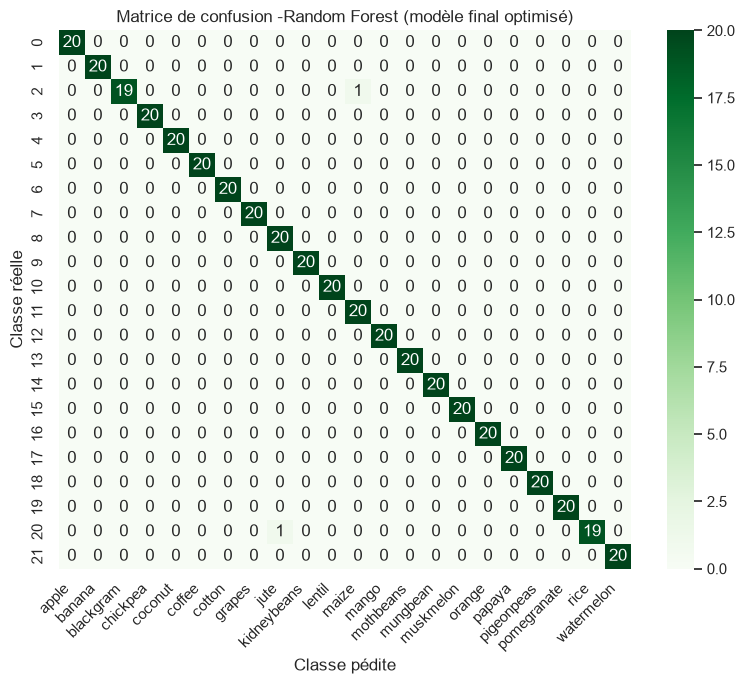

In [29]:
plt.figure(figsize=(8,7))
matrice_confusion_finale =confusion_matrix(ytest, y_pred_final)
sns.heatmap(matrice_confusion_finale, annot=True, fmt="d", cmap="Greens", xticklabels=encodeur_cible.classes_)
plt.title(f"Matrice de confusion -{nom_modele_final} (modèle final optimisé)")
plt.xlabel("Classe pédite")
plt.ylabel("Classe réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

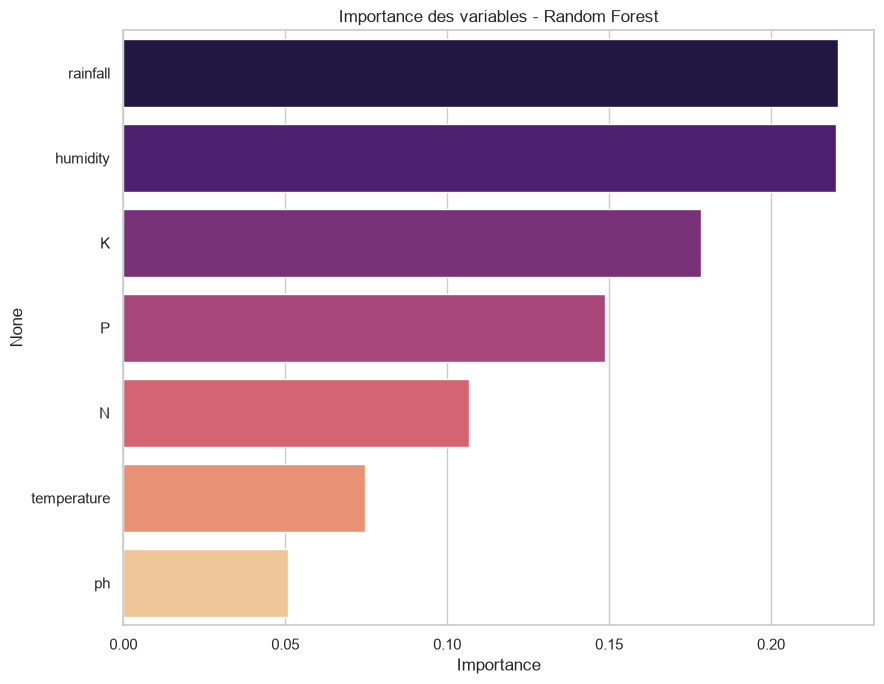

rainfall       0.220753
humidity       0.220182
K              0.178327
P              0.148808
N              0.106676
temperature    0.074563
ph             0.050691
dtype: float64


In [30]:
# Importance des variables (si le modèle final le permet)
if hasattr(modele_final, "feature_importances_"):
    importances = pd.Series(modele_final.feature_importances_, index=num_cols)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(9,7))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="magma", legend=False)
    plt.title(f"Importance des variables - {nom_modele_final}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(importances)
else:
    print("Le modèle final ne fournit pas nativement d'importance des variables.")     

In [31]:
import os
import joblib
import json
from datetime import datetime

dossier_artefacts = "../model_artifacts"
os.makedirs(dossier_artefacts, exist_ok=True)

# Artefacts réellement utilisés par ce projet
joblib.dump(modele_final, os.path.join(dossier_artefacts, "modele_final.joblib"))
joblib.dump(scaler, os.path.join(dossier_artefacts, "scaler.joblib"))
joblib.dump(encodeur_cible, os.path.join(dossier_artefacts, "encodeur_cible.joblib"))
joblib.dump(list(num_cols), os.path.join(dossier_artefacts, "noms_features.joblib"))

# Métadonnées : utile pour savoir, plus tard, quel modèle a été déployé et avec quelle performance
metadonnees = {
    "modele": meilleur_nom,
    "date_export": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "accuracy_test": float(acc),
    "f1_macro_test": float(f1),
    "features_attendues": list(num_cols),
    "classes": list(encodeur_cible.classes_),
}
with open(os.path.join(dossier_artefacts, "metadonnees.json"), "w", encoding="utf-8") as f:
    json.dump(metadonnees, f, ensure_ascii=False, indent=2)

print("Artefacts sauvegardés dans le dossier :", dossier_artefacts)
print(os.listdir(dossier_artefacts))

Artefacts sauvegardés dans le dossier : ../model_artifacts
['encodeur_cible.joblib', 'metadonnees.json', 'modele_final.joblib', 'noms_features.joblib', 'scaler.joblib']


In [32]:
# Vérification : rechargement des artefacts et test sur un échantillon du jeu de test

modele_recharge = joblib.load(os.path.join(dossier_artefacts, "modele_final.joblib"))
scaler_recharge = joblib.load(os.path.join(dossier_artefacts, "scaler.joblib"))

echantillon = xtest.iloc[:5]                       # xtest reste un DataFrame (issu de X), .iloc fonctionne
echantillon_scaled = scaler_recharge.transform(echantillon)
predictions_rechargees = modele_recharge.predict(echantillon_scaled)
classes_predictes = encodeur_cible.inverse_transform(predictions_rechargees)

print("Prédiction du modèle rechargé sur 5 exemples du jeu de test :")
print(classes_predictes)
print("\nClasses réelles correspondantes :")
print(encodeur_cible.inverse_transform(ytest[:5]))   # ytest est un array NumPy → indexation directe, pas de .iloc/.values

Prédiction du modèle rechargé sur 5 exemples du jeu de test :
['orange' 'banana' 'cotton' 'maize' 'orange']

Classes réelles correspondantes :
['orange' 'banana' 'cotton' 'maize' 'orange']
